<a href="https://colab.research.google.com/github/Obanai4you/CSIT-LAB-WORKS/blob/main/Dataware_Housing_And_Datamining/Lab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Lab 3: Data Pre-Processing -Data Discretization, Binning and Feature Subset Selection.
****************

###1. Data Discretization
Definition:

Data discretization is the process of converting continuous data into discrete categories or intervals.

Importance:

It simplifies data, reduces complexity, and helps algorithms (like decision trees) perform better and faster.

###2. Data Binning
Definition:
Data binning is a technique of grouping continuous values into a set of “bins” or intervals.

Importance:
It reduces noise, smooths data, and makes patterns easier to detect during analysis.

###3. Feature Subset Selection

Definition:
Feature subset selection is the process of selecting the most important features from the dataset and removing irrelevant or redundant ones.

Importance:
It improves model accuracy, reduces overfitting, and decreases computation time.



##  Data Bining can be achieved by cut method  - "Cut()" will group data and apply user defined labels  

### Syntax - pd.cut(x, bins, labels = None)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
heart_data = pd.read_csv('/content/clean_heart_dataset.csv')
heart_data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


##Check Range of a Continuous Attribute (Example: Age)

In [3]:
print("Maximum Age: ", heart_data['age'].max())
print("Minimum Age: ", heart_data['age'].min())

Maximum Age:  77
Minimum Age:  29


## Create Bins (Data Binning)
  Create 3 buckets for Age:
  
  20–40 → Young

  40–60 → Middle-aged

  60–100 → Old

In [4]:
heart_data['bin'] = pd.cut(heart_data['age'], bins=[20,40,60,100])
heart_data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,bin
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0,"(40, 60]"
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0,"(40, 60]"
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0,"(60, 100]"
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0,"(60, 100]"
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0,"(60, 100]"


###Add Labels to Bins

In [5]:
heart_data['bin'] = pd.cut(
    heart_data['age'],
    bins=[20,40,60,100],
    labels=['Young','Middle-aged','Old']
)
heart_data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,bin
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0,Middle-aged
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0,Middle-aged
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0,Old
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0,Old
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0,Old


###Show Original vs Binned Values

In [7]:
dta_frm = heart_data[['age','bin']]
dta_frm.head()

,age,bin
0,52,Middle-aged
1,53,Middle-aged
2,70,Old
3,61,Old
4,62,Old


###Replace Original Column with Binned Values


In [8]:
heart_data['age'] = heart_data['bin'].values
heart_data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,bin
0,Middle-aged,1,0,125,212,0,1,168,0,1.0,2,2,3,0,Middle-aged
1,Middle-aged,1,0,140,203,1,0,155,1,3.1,0,0,3,0,Middle-aged
2,Old,1,0,145,174,0,1,125,1,2.6,0,0,3,0,Old
3,Old,1,0,148,203,0,1,161,0,0.0,2,1,3,0,Old
4,Old,0,0,138,294,1,1,106,0,1.9,1,3,2,0,Old


###Drop Bin Column

In [9]:
heart_data.drop(['bin'], axis=1, inplace=True)
heart_data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,Middle-aged,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,Middle-aged,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,Old,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,Old,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,Old,0,0,138,294,1,1,106,0,1.9,1,3,2,0


##Data Binarization

Data binarization is the process of converting categorical data into binary (0 and 1) format so that it can be used in machine learning models. In this lab, after performing data discretization on the age attribute (converting it into categories like Young, Middle-aged, and Old), binarization was applied.

The pd.get_dummies() function was used to transform these categorical values into separate binary columns. Each category is represented by a new column, where:

1 indicates the presence of that category
0 indicates the absence

This step is important because most machine learning algorithms require numerical input and cannot directly process categorical data. Binarization ensures that the categorical information is preserved without implying any ordinal relationship between categories.

###Step 1: Check categorical values

Before binarization, we check the categories present in the age attribute.

In [10]:
heart_data['age'].value_counts()

,count
age,
Middle-aged,205
Old,79
Young,18


###Step 2: Apply One-Hot Encoding

Data binarization is performed using pd.get_dummies() to convert categorical values into binary format.

In [12]:
pd.get_dummies(heart_data['age'])

,Young,Middle-aged,Old
0,False,True,False
1,False,True,False
2,False,False,True
3,False,False,True
4,False,False,True
...,...,...,...
297,False,False,True
298,False,True,False
299,False,True,False
300,False,True,False


###Step 3: Convert categories into binary columns

Each category is converted into a separate column where:

1 → presence
0 → absence

In [13]:
heart_data = pd.get_dummies(heart_data, columns=['age'])
heart_data.head()

,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,age_Young,age_Middle-aged,age_Old
0,1,0,125,212,0,1,168,0,1.0,2,2,3,0,False,True,False
1,1,0,140,203,1,0,155,1,3.1,0,0,3,0,False,True,False
2,1,0,145,174,0,1,125,1,2.6,0,0,3,0,False,False,True
3,1,0,148,203,0,1,161,0,0.0,2,1,3,0,False,False,True
4,0,0,138,294,1,1,106,0,1.9,1,3,2,0,False,False,True


##Feature Subset Selection (Filter Approach)

Feature Subset Selection is the process of selecting only the most relevant features from a dataset while removing unnecessary ones. The filter approach uses statistical methods like correlation to select important features without using any machine learning model.

###Step 1: Select numerical features

Only numerical attributes are used for correlation analysis.

In [14]:
heart_data.select_dtypes(include=np.number).head()

,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,0,0,138,294,1,1,106,0,1.9,1,3,2,0


###Step 2: Compute correlation

Correlation measures the relationship between features.

In [15]:
corr_matrix = heart_data.corr()
corr_matrix

,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,age_Young,age_Middle-aged,age_Old
sex,1.000000,-0.051740,-0.057647,-0.195571,0.046022,-0.060351,-0.046439,0.143460,0.098322,-0.032990,0.113060,0.211452,-0.283609,0.021682,0.124354,-0.143796
cp,-0.051740,1.000000,0.046486,-0.072682,0.096018,0.041561,0.293367,-0.392937,-0.146692,0.116854,-0.195356,-0.160370,0.432080,0.090347,-0.024317,-0.022833
trestbps,-0.057647,0.046486,1.000000,0.125256,0.178125,-0.115367,-0.048023,0.068526,0.194600,-0.122873,0.099248,0.062870,-0.146269,-0.077251,-0.131661,0.181493
chol,-0.195571,-0.072682,0.125256,1.000000,0.011428,-0.147602,-0.005308,0.064099,0.050086,0.000417,0.086878,0.096810,-0.081437,-0.153486,-0.070204,0.157266
fbs,0.046022,0.096018,0.178125,0.011428,1.000000,-0.083081,-0.007169,0.024729,0.004514,-0.058654,0.144935,-0.032752,-0.026826,-0.105346,0.028949,0.025992
restecg,-0.060351,0.041561,-0.115367,-0.147602,-0.083081,1.000000,0.041210,-0.068807,-0.056251,0.090402,-0.083112,-0.010473,0.134874,0.093832,0.014443,-0.065889
thalach,-0.046439,0.293367,-0.048023,-0.005308,-0.007169,0.041210,1.000000,-0.377411,-0.342201,0.384754,-0.228311,-0.094910,0.419955,0.217603,0.144290,-0.270515
exang,0.143460,-0.392937,0.068526,0.064099,0.024729,-0.068807,-0.377411,1.000000,0.286766,-0.256106,0.125377,0.205826,-0.435601,-0.026835,-0.003051,0.017698
oldpeak,0.098322,-0.146692,0.194600,0.050086,0.004514,-0.056251,-0.342201,0.286766,1.000000,-0.576314,0.236560,0.209090,-0.429146,-0.038295,-0.129806,0.158537
slope,-0.032990,0.116854,-0.122873,0.000417,-0.058654,0.090402,0.384754,-0.256106,-0.576314,1.000000,-0.092236,-0.103314,0.343940,0.087468,0.063890,-0.114995


###Step 3: Visualize correlation

Heatmap helps to easily identify strong relationships.

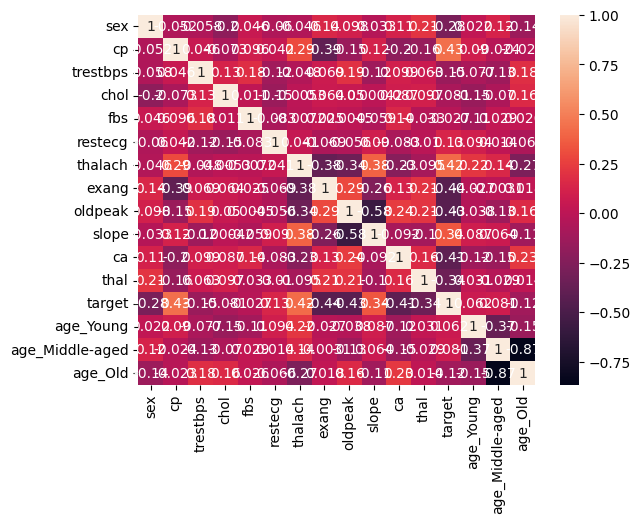

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(corr_matrix, annot=True)
plt.show()

###Step 4: Select important features

Features highly correlated with the target are selected.

In [17]:
corr_matrix['target'].sort_values(ascending=False)

,target
target,1.000000
cp,0.432080
thalach,0.419955
slope,0.343940
restecg,0.134874
age_Middle-aged,0.080795
age_Young,0.062476
fbs,-0.026826
chol,-0.081437
age_Old,-0.119493


###Step 5: Remove less important features

Features with low correlation can be removed.

In [20]:
heart_data.drop(['column_name'], axis=1, errors='ignore', inplace=True)

##Conclusion
******************
In this experiment (Lab 3), the dataset was loaded and explored to understand its structure and attributes. Basic data preprocessing steps were performed, including handling missing or unnecessary columns and correcting dataset issues encountered during processing.

Data binarization was applied to convert continuous or categorical values into binary form to simplify analysis. After that, feature selection was performed using the filter approach to identify and retain only the most relevant attributes based on statistical importance.

These steps helped in reducing dataset complexity, improving data quality, and preparing the dataset for further machine learning tasks. The experiment highlights the importance of preprocessing techniques such as binarization and feature selection in building efficient and accurate models.